# Generate test images and fake aquisition from the mnt data
In this notebook, we present the steps that will generate sythetic bedrock depth of a glacier using DEM data.  
The logic is the following :
1. Input a DEM raster, of the past glacial covered zone. 
2. Cut some random extend of this DEM, and generate some synthetic bedrock depth data. 
3. Generate a training image for the MPS that does not include the zone of interest (to avoid a perfect match, because TI == Simulated)
4. Export

### input : 
Georeferenced DEM (In metrics coordinates). No data is defined as the minimum value. (In our case we took -1e38)

### settings : 
Density of fake GPR aquisition lines of the zone  
Error to be added to the data (to simulate picking and wavelenght imprecision)  
Number of acquisition to produce


### output :
Generation of .pickle binary files to be open with the simulation script




In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random


import tkinter as tk
from tkinter import filedialog

C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\pysal\explore\segregation\network\network.py:16: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  "You need pandana and urbanaccess to work with segregation's network module\n"


## Intro :
We define here the parameters, and the training image in which we will cut the data.`file_path = './datas/TI/MNT_2016_TI_Alt2.tif'`  
Size of the cutted image in [m] `size_img = np.array([400,400])`  
Number of GPR profile in an image `number_of_aquisition_lines = 3`  
Do we want to define the border of the zone (as i would be in a real case, because the border of the glacier altitude = bedrock altitute) ? `define_border = True`  
Error to add to the data [m] and number of random aquisition on the image. `error = 2
num_img = 3`



In [2]:
#Load the data
file_path = './data/TI/tif/ti_alti2_2016_2m.tif'
size_img = np.array([400,400])
number_of_aquisition_lines = 3
define_border = True
error = 2
num_img = 3

data_DEM = gr.from_file(file_path)
(xmin, xsize, x, ymax, y, ysize) = data_DEM.geot


We recover the size, origin and resolution of the input data.  
We also create a mask.

In [3]:
print('Sizes Infos :')

print(data_DEM.geot)
print('Number of cells :')

print(data_DEM.shape)
x_v = np.array(range(data_DEM.shape[1]))*data_DEM.geot[1] + data_DEM.geot[0]
y_v = np.array(range(data_DEM.shape[0]))*data_DEM.geot[5] + data_DEM.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)


Sizes Infos :
(583242.0, 2.0, 0.0, 131224.0, 0.0, -2.0)
Number of cells :
(1557, 2967)


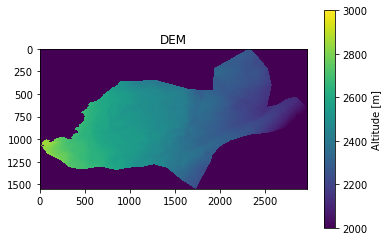

In [4]:
plt.imshow(data_DEM.raster)
a = plt.colorbar()
a.set_label('Altitude [m]')
plt.clim(2000, 3000)
plt.title('DEM')
plt.show()

Text(0.5, 1.0, 'Masked data')

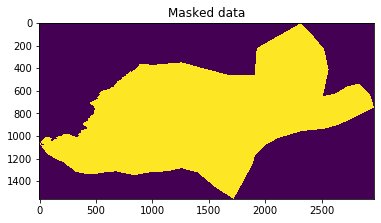

In [5]:
mask_where_nodata = data_DEM.raster != np.min(data_DEM.raster)

plt.imshow(mask_where_nodata)
plt.title('Masked data')



## Random Choice
We take a random square in the DEM. If the square is entirely in the mask, we keep it. If the mask if partially or not in the mask, we loop again.  
The position of the zone at each iteration is shown below.

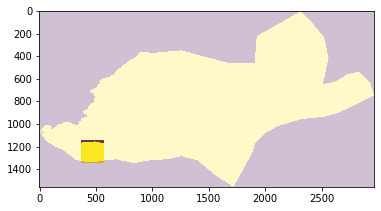

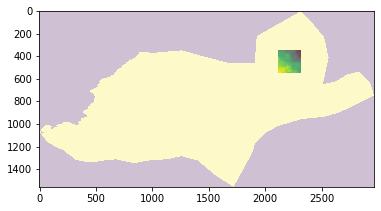

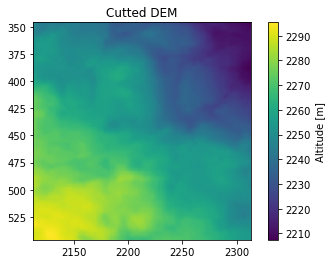

In [6]:
res = False

while res == False:
    plt.close()
    size_img_c = (np.round(size_img / data_DEM.geot[1]))
    rdm_X = int(round(random()*(data_DEM.shape[1] - size_img_c[0])))
    rdm_Y = int(round(random()*(data_DEM.shape[0] - size_img_c[1])))

    box = [rdm_X, int(rdm_X+size_img_c[0]),rdm_Y,int(rdm_Y+size_img_c[1])]
    mask_cut = mask_where_nodata[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    raster_cut = data_DEM.raster[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    New_TI = np.array(data_DEM.raster)
    New_TI[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))] = data_DEM.nodata_value
    
    mask = np.zeros(data_DEM.shape)
    mask[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))] = 1

    res = np.all(mask_cut)
    #a = np.ones(raster_cut.shape)*100000000
    plt.imshow(raster_cut, extent = box)
    plt.imshow(data_DEM.raster,alpha=0.25)
    
    plt.show()
    time.sleep(0.5)
    
plt.figure()
plt.imshow(raster_cut, extent = box)
plt.gca().invert_yaxis()
plt.title('Cutted DEM')
a = plt.colorbar()
a.set_label('Altitude [m]')
plt.show()



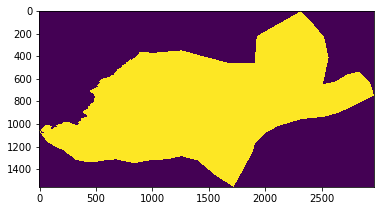

In [7]:
plt.imshow(mask_where_nodata)

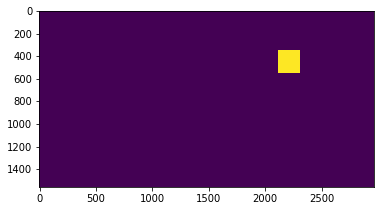

In [8]:
plt.imshow(mask)

## Definition of the hard data
 We will generate all the hard-data in the follwing cells. This include the random GPR lines and the definition of the border of the image.


In [9]:
hard_data = pd.DataFrame()
line = np.zeros([2,2])

for i in range(number_of_aquisition_lines):

    top = [round(random()),round(random())]
    if top[0] == 1:  #Vertical start
        line[:,0] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[2]])#return a x value, defined a y
    else:
        line[:,0] = np.array([box[0],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y

    if top[1] == 1:
        line[:,1] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[3]]) #return a x value, defined a y
    else:
        line[:,1] = np.array([box[1],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y

    dx = int(np.max(np.diff(line)))

    x_pos = np.round(np.linspace(line[0,0],line[0,1],num =dx))
    y_pos = np.round(np.linspace(line[1,0],line[1,1],num =dx))

    d = {'cell_x': x_pos, 'cell_y': y_pos}
    pos_index = pd.DataFrame(d)
    pos_index["cell_x"] = pos_index["cell_x"].astype(int)
    pos_index["cell_y"] = pos_index["cell_y"].astype(int)
    pos_index['alt'] = data_DEM.raster[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['X'] = X_dem[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['Y'] = Y_dem[pos_index["cell_y"],pos_index["cell_x"]]

    hard_data = hard_data.append(pos_index, ignore_index = True)


(2102.9783154121865, 2323.021684587814, 337.6348233995585, 521.3651766004415)

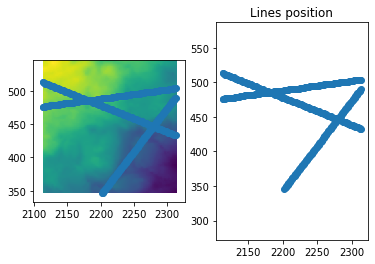

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plt.title('Lines position')

ax1.imshow(raster_cut, extent = box)
ax1.scatter(hard_data["cell_x"],hard_data["cell_y"] )

ax2.scatter(hard_data["cell_x"],hard_data["cell_y"])
plt.axis('equal')

In [11]:
if define_border:
    x_cells = np.array(range(box[0],box[1]))
    y_cells = np.array(range(box[2],box[3]))
    
    x_pos = np.append(np.tile(x_cells,2),np.tile(x_cells[0],y_cells.size))#,)
    y_pos = np.append(np.tile(y_cells[0],x_cells.size),np.tile(y_cells[-1],x_cells.size))#)
    
    x_pos = np.append(x_pos,np.tile(x_cells[-1],y_cells.size))
    y_pos = np.append(y_pos,np.tile(y_cells,2))
    #x_pos = x_pos.append()
    
    d = {'cell_x': x_pos, 'cell_y': y_pos}
    pos_index = pd.DataFrame(d)
    pos_index["cell_x"] = pos_index["cell_x"].astype(int)
    pos_index["cell_y"] = pos_index["cell_y"].astype(int)
    
    pos_index['alt'] = data_DEM.raster[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['X'] = X_dem[pos_index["cell_y"],pos_index["cell_x"]]
    pos_index['Y'] = Y_dem[pos_index["cell_y"],pos_index["cell_x"]]
    
    hard_data = hard_data.append(pos_index, ignore_index = True)


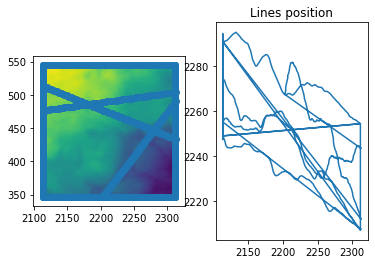

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plt.title('Lines position')

ax1.imshow(raster_cut, extent = box)
ax1.scatter(hard_data["cell_x"],hard_data["cell_y"] )

ax2.plot(hard_data["cell_x"],hard_data["alt"])

## Export

In [13]:
synthe_name = 'realisation' 
save_path = './generated_data'
if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)



In [14]:
with open(save_path + '/' + synthe_name + str(1) + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([raster_cut.data, box, hard_data,New_TI,[mask,mask_where_nodata]], f, pickle.HIGHEST_PROTOCOL)

,cell_x,cell_y,alt,X,Y
0,2113,476,2274.582520,587468.0,130272.0
1,2114,476,2274.107666,587470.0,130272.0
2,2115,476,2273.651367,587472.0,130272.0
3,2116,476,2273.228760,587474.0,130272.0
4,2117,477,2272.061035,587476.0,130270.0
...,...,...,...,...,...
1339,2312,541,2209.186523,587866.0,130142.0
1340,2312,542,2208.341064,587866.0,130140.0
1341,2312,543,2207.965332,587866.0,130138.0
1342,2312,544,2207.671875,587866.0,130136.0
